In [ ]:
!pip install torch torchvision timm pillow

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import timm
import os

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# DINOv2 model (ViT-Small for lighter usage)
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model.to(device)
model.eval()

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 145MB/s]


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affi

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def load_images(folder):
    images = []
    for fname in os.listdir(folder):
        if fname.endswith(".tif") or fname.endswith(".tiff"):
            img = Image.open(os.path.join(folder, fname)).convert("RGB")
            img = transform(img)
            images.append(img)
    return torch.stack(images)

data = load_images("/content/drive/MyDrive/RSE_Project_Spring_26/1400").to(device)

In [ ]:
import os

folder_path = "/content/drive/MyDrive/RSE_Project_Spring_26/1200"

image_extensions = (".tif", ".tiff", ".jpg", ".jpeg", ".png")

image_count = 0
for filename in os.listdir(folder_path):
    if filename.lower().endswith(image_extensions):
        image_count += 1

print(f"Number of images in the folder: {image_count}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/RSE_Project_Spring_26/1200'

In [ ]:
with torch.no_grad():
    embeddings = model(data)  # shape: [N, 384]

In [ ]:
class Decoder(nn.Module):
    def __init__(self, emb_dim=384):
        super().__init__()
        self.fc = nn.Linear(emb_dim, 256 * 8 * 8)
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),     # 64x64
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 8, 8)
        x = self.conv(x)
        return x

decoder = Decoder().to(device)

In [ ]:
optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3)

for epoch in range(20):
    optimizer.zero_grad()

    recon = decoder(embeddings)

    # Resize original to 64×64
    target = F.interpolate(data, size=(64, 64))

    loss = F.mse_loss(recon, target)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.0259
Epoch 1, Loss: 0.0196
Epoch 2, Loss: 0.0172
Epoch 3, Loss: 0.0136
Epoch 4, Loss: 0.0121
Epoch 5, Loss: 0.0108
Epoch 6, Loss: 0.0096
Epoch 7, Loss: 0.0087
Epoch 8, Loss: 0.0082
Epoch 9, Loss: 0.0079
Epoch 10, Loss: 0.0075
Epoch 11, Loss: 0.0073
Epoch 12, Loss: 0.0071
Epoch 13, Loss: 0.0070
Epoch 14, Loss: 0.0068
Epoch 15, Loss: 0.0067
Epoch 16, Loss: 0.0066
Epoch 17, Loss: 0.0065
Epoch 18, Loss: 0.0064
Epoch 19, Loss: 0.0064


In [ ]:
# sample random embeddings
z = torch.randn(10, 384).to(device)

generated = decoder(z)  # [10, 3, 64, 64]

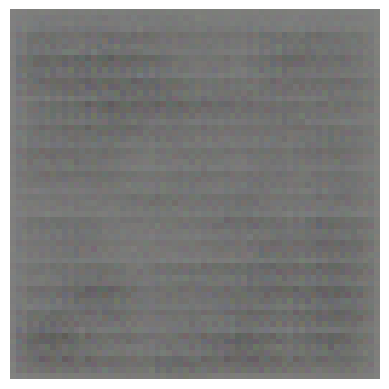

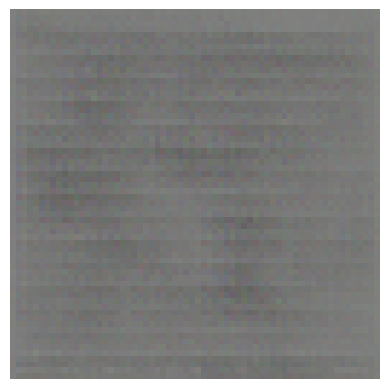

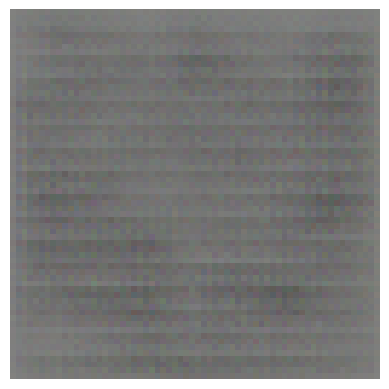

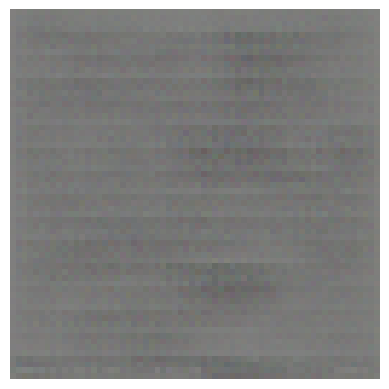

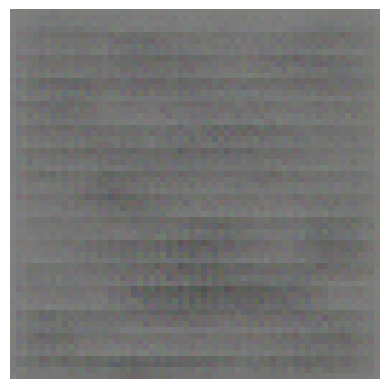

In [ ]:
import matplotlib.pyplot as plt

imgs = generated.detach().cpu()

for i in range(5):
    plt.imshow(imgs[i].permute(1,2,0))
    plt.axis('off')
    plt.show()

###DinoV2 Encoder+VAE latent+Decoder

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


DINO embedding dim: 384
Epoch 1/50 | loss=0.01913
Epoch 2/50 | loss=0.01532
Epoch 3/50 | loss=0.01177
Epoch 4/50 | loss=0.00817
Epoch 5/50 | loss=0.00597
Epoch 6/50 | loss=0.00527
Epoch 7/50 | loss=0.00494
Epoch 8/50 | loss=0.00478
Epoch 9/50 | loss=0.00463
Epoch 10/50 | loss=0.00457
Epoch 11/50 | loss=0.00447
Epoch 12/50 | loss=0.00440
Epoch 13/50 | loss=0.00433
Epoch 14/50 | loss=0.00429
Epoch 15/50 | loss=0.00422
Epoch 16/50 | loss=0.00419
Epoch 17/50 | loss=0.00414
Epoch 18/50 | loss=0.00410
Epoch 19/50 | loss=0.00407
Epoch 20/50 | loss=0.00407
Epoch 21/50 | loss=0.00402
Epoch 22/50 | loss=0.00399
Epoch 23/50 | loss=0.00396
Epoch 24/50 | loss=0.00397
Epoch 25/50 | loss=0.00396
Epoch 26/50 | loss=0.00395
Epoch 27/50 | loss=0.00392
Epoch 28/50 | loss=0.00393
Epoch 29/50 | loss=0.00392
Epoch 30/50 | loss=0.00389
Epoch 31/50 | loss=0.00386
Epoch 32/50 | loss=0.00389
Epoch 33/50 | loss=0.00388
Epoch 34/50 | loss=0.00387
Epoch 35/50 | loss=0.00385
Epoch 36/50 | loss=0.00384
Epoch 37/50 |

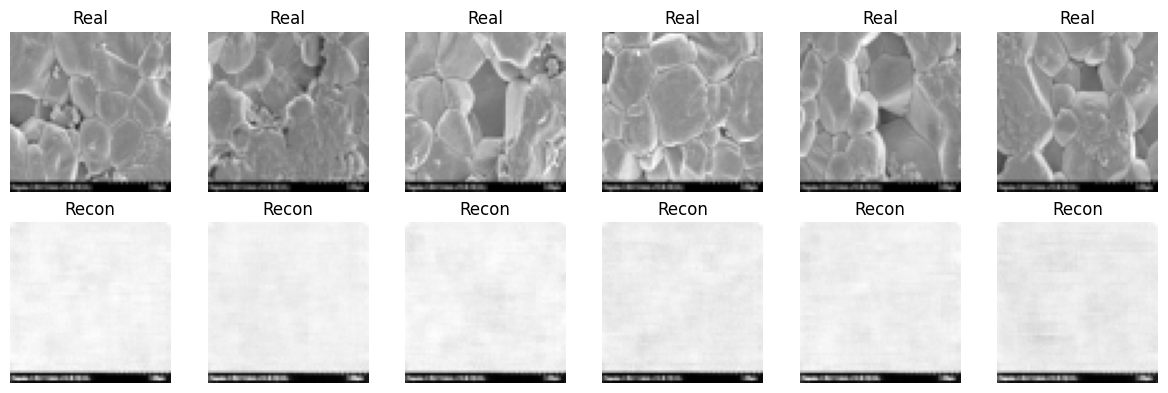

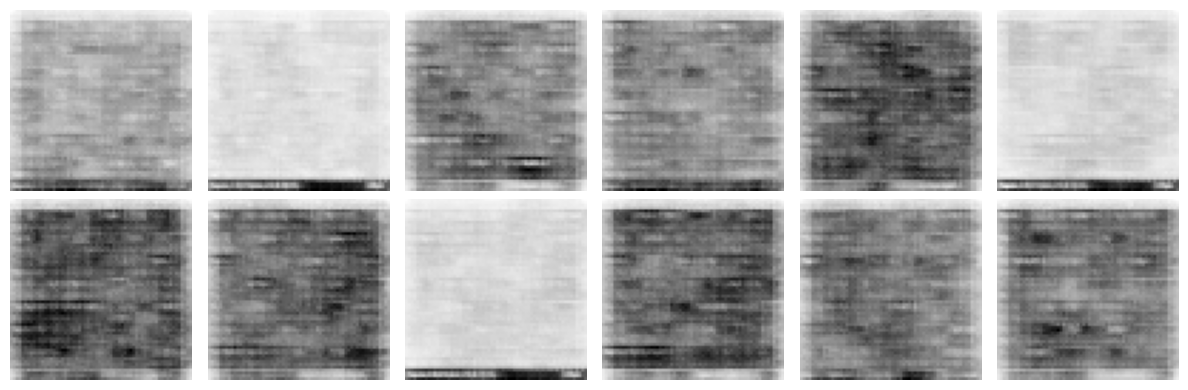

In [ ]:

import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

# =========================================================
# Config
# =========================================================
DATA_DIR = "/content/1400"
BATCH_SIZE = 16
LATENT_DIM = 64
EPOCHS = 50
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# Dataset
# =========================================================
class TiffDataset(Dataset):
    def __init__(self, folder):
        self.files = sorted(
            glob.glob(os.path.join(folder, "*.tif")) +
            glob.glob(os.path.join(folder, "*.tiff"))
        )
        self.transform_dino = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),  # DINO expects 3 channels
            transforms.ToTensor(),
        ])
        self.transform_target = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("L")
        x_dino = self.transform_dino(img)     # [3,224,224]
        x_target = self.transform_target(img) # [1,64,64]
        return x_dino, x_target

dataset = TiffDataset(DATA_DIR)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# =========================================================
# DINOv2 encoder
# =========================================================
dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dino.eval().to(DEVICE)

for p in dino.parameters():
    p.requires_grad = False

# figure out DINO embedding dim
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    dummy_feat = dino(dummy)
    DINO_DIM = dummy_feat.shape[-1]

print("DINO embedding dim:", DINO_DIM)

# =========================================================
# VAE on top of DINO features
# =========================================================
class DinoVAE(nn.Module):
    def __init__(self, dino_dim=DINO_DIM, latent_dim=LATENT_DIM):
        super().__init__()

        # VAE encoder from DINO features -> latent params
        self.fc_mu = nn.Sequential(
            nn.Linear(dino_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.fc_logvar = nn.Sequential(
            nn.Linear(dino_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        # latent -> image decoder
        self.decoder_input = nn.Linear(latent_dim, 256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # 64x64
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, feat):
        mu = self.fc_mu(feat)
        logvar = self.fc_logvar(feat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 256, 8, 8)
        return self.decoder(x)

    def forward(self, feat):
        mu, logvar = self.encode(feat)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

model = DinoVAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# =========================================================
# Loss
# =========================================================
def vae_loss(recon, target, mu, logvar, beta=1e-3):
    recon_loss = F.mse_loss(recon, target, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl

# =========================================================
# Train
# =========================================================
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for x_dino, x_target in loader:
        x_dino = x_dino.to(DEVICE)
        x_target = x_target.to(DEVICE)

        with torch.no_grad():
            feat = dino(x_dino)

        recon, mu, logvar = model(feat)
        loss, recon_loss, kl = vae_loss(recon, x_target, mu, logvar, beta=1e-3)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_loss/len(loader):.5f}")

# =========================================================
# Show reconstructions
# =========================================================
model.eval()
x_dino, x_target = next(iter(loader))
x_dino = x_dino.to(DEVICE)
x_target = x_target.to(DEVICE)

with torch.no_grad():
    feat = dino(x_dino)
    recon, _, _ = model(feat)

x_target = x_target.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(x_target[i, 0], cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Real")

    axes[1, i].imshow(recon[i, 0], cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Recon")
plt.tight_layout()
plt.show()

# =========================================================
# Generate NEW images
# =========================================================
with torch.no_grad():
    z = torch.randn(12, LATENT_DIM).to(DEVICE)
    samples = model.decode(z).cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(12):
    axes[i // 6, i % 6].imshow(samples[i, 0], cmap="gray")
    axes[i // 6, i % 6].axis("off")
plt.tight_layout()
plt.show()

In [ ]:

import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

# =========================================================
# Config
# =========================================================
DATA_DIR = "/content/1400"
BATCH_SIZE = 16
LATENT_DIM = 64
EPOCHS = 50
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# Dataset
# =========================================================
class TiffDataset(Dataset):
    def __init__(self, folder):
        self.files = sorted(
            glob.glob(os.path.join(folder, "*.tif")) +
            glob.glob(os.path.join(folder, "*.tiff"))
        )
        self.transform_dino = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),  # DINO expects 3 channels
            transforms.ToTensor(),
        ])
        self.transform_target = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("L")
        x_dino = self.transform_dino(img)     # [3,224,224]
        x_target = self.transform_target(img) # [1,64,64]
        return x_dino, x_target

dataset = TiffDataset(DATA_DIR)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# =========================================================
# DINOv2 encoder
# =========================================================
dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dino.eval().to(DEVICE)

for p in dino.parameters():
    p.requires_grad = False

# figure out DINO embedding dim
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    dummy_feat = dino(dummy)
    DINO_DIM = dummy_feat.shape[-1]

print("DINO embedding dim:", DINO_DIM)

# =========================================================
# VAE on top of DINO features
# =========================================================
class DinoVAE(nn.Module):
    def __init__(self, dino_dim=DINO_DIM, latent_dim=LATENT_DIM):
        super().__init__()

        # VAE encoder from DINO features -> latent params
        self.fc_mu = nn.Sequential(
            nn.Linear(dino_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.fc_logvar = nn.Sequential(
            nn.Linear(dino_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        # latent -> image decoder
        self.decoder_input = nn.Linear(latent_dim, 256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # 64x64
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, feat):
        mu = self.fc_mu(feat)
        logvar = self.fc_logvar(feat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 256, 8, 8)
        return self.decoder(x)

    def forward(self, feat):
        mu, logvar = self.encode(feat)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

model = DinoVAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# =========================================================
# Loss
# =========================================================
def vae_loss(recon, target, mu, logvar, beta=1e-3):
    recon_loss = F.mse_loss(recon, target, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl

# =========================================================
# Train
# =========================================================
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for x_dino, x_target in loader:
        x_dino = x_dino.to(DEVICE)
        x_target = x_target.to(DEVICE)

        with torch.no_grad():
            feat = dino(x_dino)

        recon, mu, logvar = model(feat)
        loss, recon_loss, kl = vae_loss(recon, x_target, mu, logvar, beta=1e-3)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | loss={total_loss/len(loader):.5f}")

# =========================================================
# Show reconstructions
# =========================================================
model.eval()
x_dino, x_target = next(iter(loader))
x_dino = x_dino.to(DEVICE)
x_target = x_target.to(DEVICE)

with torch.no_grad():
    feat = dino(x_dino)
    recon, _, _ = model(feat)

x_target = x_target.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(x_target[i, 0], cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Real")

    axes[1, i].imshow(recon[i, 0], cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Recon")
plt.tight_layout()
plt.show()

# =========================================================
# Generate NEW images
# =========================================================
with torch.no_grad():
    z = torch.randn(12, LATENT_DIM).to(DEVICE)
    samples = model.decode(z).cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(12):
    axes[i // 6, i % 6].imshow(samples[i, 0], cmap="gray")
    axes[i // 6, i % 6].axis("off")
plt.tight_layout()
plt.show()